# Three-way extraction comparison: InternVL3.5-8B (production) vs Qwen 3.8 27B vs Gemma 4 31B

**Same 165 documents** (55 invoices, 55 receipts, 55 bank statements), **same answer key,
same corrected scorer**, measured 2026-09-21/22. Each model is served as it would be in
production — the one engine, precision and topology it was validated on — so the
InternVL row is a *deployment* baseline, while Gemma vs Qwen (identical engine and cards)
is a controlled pair. Write-up: `plans/2026-09-22-gemma4-31b-vs-qwen38-27b-RESULTS.md`.

Figures are exported to `notebooks/figures/three_way_20260922/` for slides.

In [1]:
import json
import os
import re
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch


def repo_root() -> Path:
    """Find the LMM_POC checkout by walking up from the working directory.

    Jupyter sets the kernel's cwd to the notebook's own directory, so this anchors the
    figure export path on the repo rather than on wherever the kernel happens to start.
    """
    for directory in (Path.cwd(), *Path.cwd().parents):
        if (directory / "common" / "field_schema.py").is_file():
            return directory
    raise ModuleNotFoundError(
        f"Could not find the LMM_POC checkout from {Path.cwd()}.\n"
        "  Expected: this notebook to sit inside the repository (notebooks/ is fine).\n"
        "  Fix: open it from within the repo, or start the kernel there."
    )


REPO_ROOT = repo_root()

# Chart chrome: a light surface, ink for text, hairline recessive grid. Series colour is
# reserved for marks; text never wears it.
SURFACE, INK, INK_2, MUTED, GRID, BASELINE = (
    "#fcfcfb",
    "#0b0b0b",
    "#52514e",
    "#898781",
    "#e1e0d9",
    "#c3c2b7",
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "font.family": "sans-serif",
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_2,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "text.color": INK,
        "grid.color": GRID,
        "grid.linewidth": 1.0,
        "grid.linestyle": "-",
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "legend.frameon": False,
    }
)

# Fixed entity order and fixed hues (categorical slots 1-3, validated all-pairs for the
# small multiples below). Colour follows the model, never its rank.
MODELS = ["InternVL3.5-8B", "Qwen 3.8 27B", "Gemma 4 31B"]
PRODUCTION = "InternVL3.5-8B"
MODEL_COLOUR = {"InternVL3.5-8B": "#2a78d6", "Qwen 3.8 27B": "#eb6834", "Gemma 4 31B": "#1baf7a"}
MODEL_SERVED = {
    "InternVL3.5-8B": "BF16 · DP=2, tp=1 · vLLM 0.19.0",
    "Qwen 3.8 27B": "FP8 · tp=2 · vLLM 0.29.0",
    "Gemma 4 31B": "QAT W4A16 · tp=2 · vLLM 0.29.0",
}
DOC_LABEL = {"BANK_STATEMENT": "Bank statement", "INVOICE": "Invoice", "RECEIPT": "Receipt"}
DOC_ORDER = ["BANK_STATEMENT", "INVOICE", "RECEIPT"]

# How many independent engines each run had: an 8B fits one 24 GiB card so it ran two
# (DP=2); the larger models were sharded across both cards (tp=2) and ran one.
ENGINES_MEASURED = {"InternVL3.5-8B": 2, "Qwen 3.8 27B": 1, "Gemma 4 31B": 1}

## Where the run directories are

The three runs were downloaded from the sandbox as-is. More than one candidate root is an
error, not a preference order: two roots holding runs from either side of a fix would let
the notebook report superseded numbers with nothing to show for it.

In [2]:
SANDBOX_ROOT = Path("/home/jovyan/nfs_share/tod_2026/evaluation_data")
CANDIDATE_ROOTS = [SANDBOX_ROOT, Path.home() / "Desktop" / "evaluation_data"]

RUN_DIRS = {
    "InternVL3.5-8B": "output_internvl_20260922",
    "Qwen 3.8 27B": "output_qwen38_20260921",
    "Gemma 4 31B": "output_gemma31b_20260921",
}
# The registered model type each run must have loaded -- used to pick the right
# entrypoint log when a directory holds more than one (a re-score writes its own).
MODEL_TYPE = {
    "InternVL3.5-8B": "internvl3-vllm",
    "Qwen 3.8 27B": "qwen38-27b-fp8-vllm",
    "Gemma 4 31B": "gemma4-31b-w4a16-vllm",
}


def locate_root() -> Path:
    """Resolve the results root, refusing to guess between candidates."""
    override = os.environ.get("LMM_EVAL_ROOT")
    if override:
        root = Path(override)
        missing = [d for d in RUN_DIRS.values() if not (root / d).is_dir()]
        if missing:
            raise FileNotFoundError(f"LMM_EVAL_ROOT={root} lacks run dir(s): {missing}")
        return root
    hits = [r for r in CANDIDATE_ROOTS if all((r / d).is_dir() for d in RUN_DIRS.values())]
    if len(hits) != 1:
        raise FileNotFoundError(
            f"Expected exactly one root holding all three run dirs, found {len(hits)}: {hits}\n"
            f"  Looked in: {CANDIDATE_ROOTS}\n"
            "  Fix: set LMM_EVAL_ROOT to the directory that holds " + ", ".join(RUN_DIRS.values())
        )
    return hits[0]


EVAL_ROOT = locate_root()
print("results root:", EVAL_ROOT)

results root: /Users/tod/Desktop/evaluation_data


## Load the three runs

Per-document and per-field scores come from each run's `evaluation_results.jsonl`;
extract-stage timing from `.stage_timing.jsonl` (engine load is wall clock minus
inference, which reproduces the one printed value exactly); full-pipeline totals and the
classify phase from the entrypoint log's timestamped phase markers; response lengths from
`raw_extractions.jsonl`. Every run must hold the same 165 image names, or this is not a
comparison.

In [3]:
def load_jsonl(path: Path) -> list[dict]:
    with path.open() as handle:
        return [json.loads(line) for line in handle if line.strip()]


def field_f1(entry: dict | None) -> float | None:
    if entry is None:
        return None
    if "f1_score" in entry:
        return float(entry["f1_score"])
    if "f1" in entry:
        return float(entry["f1"])
    p, r = entry.get("precision", 0.0), entry.get("recall", 0.0)
    return 2 * p * r / (p + r) if (p + r) else 0.0


PHASE_RE = re.compile(r"^\[(\d{4}-\d\d-\d\d \d\d:\d\d:\d\d)\]\s+Phase (\d)/4: (\w+)(?: \(| complete)")
EXIT_RE = re.compile(r"Exited with code 0 after (\d+)s")


def select_run_log(run: Path, model_type: str) -> Path:
    """The entrypoint log that ran THIS model through all four phases to completion."""
    candidates = []
    for log in sorted((run / "logs").glob("entrypoint_*.log")):
        text = log.read_text(errors="ignore")
        if (
            f"Loading {model_type} via vLLM" in text
            and "Phase 4/4: evaluate complete" in text
            and EXIT_RE.search(text)
        ):
            candidates.append(log)
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"{run.name}: expected one complete run log for {model_type}, found {len(candidates)}"
        )
    return candidates[0]


def phase_seconds(log: Path) -> dict:
    """classify / extract phase durations and the full-pipeline total, from timestamps."""
    starts, ends = {}, {}
    for line in log.read_text(errors="ignore").splitlines():
        m = PHASE_RE.match(line)
        if not m:
            continue
        ts, phase = datetime.strptime(m[1], "%Y-%m-%d %H:%M:%S"), m[3]
        if "complete" in line:
            ends[phase] = ts
        else:
            starts.setdefault(phase, ts)
    total = int(EXIT_RE.search(log.read_text(errors="ignore"))[1])
    return {
        "classify_s": (ends["classify"] - starts["classify"]).total_seconds(),
        "extract_s": (ends["extract"] - starts["extract"]).total_seconds(),
        "total_s": float(total),
    }


doc_rows, field_rows, image_rows, timing = [], [], [], {}
image_sets = {}
for model, dirname in RUN_DIRS.items():
    run = EVAL_ROOT / dirname
    results = list(run.rglob("evaluation_results.jsonl"))
    assert len(results) == 1, f"{dirname}: expected one evaluation_results.jsonl, found {len(results)}"
    evaluations = load_jsonl(results[0])
    image_sets[model] = {r["image_name"] for r in evaluations}
    for r in evaluations:
        doc_rows.append(
            {
                "model": model,
                "image_name": r["image_name"],
                "document_type": r["document_type"],
                "overall_accuracy": r.get("overall_accuracy", 0.0),
                "median_f1": r.get("median_f1", 0.0),
            }
        )
        for field, entry in r.get("field_scores", {}).items():
            field_rows.append(
                {
                    "model": model,
                    "image_name": r["image_name"],
                    "document_type": r["document_type"],
                    "field": field,
                    "f1": field_f1(entry),
                }
            )

    stage = load_jsonl(run / ".stage_timing.jsonl")[-1]
    assert stage["stage"] == "extract", f"{dirname}: unexpected stage timing {stage}"
    phases = phase_seconds(select_run_log(run, MODEL_TYPE[model]))
    # The stage file and the log measure the same phase two ways; they must agree.
    assert abs(phases["extract_s"] - stage["wall_clock"]) < 15, (
        model,
        phases["extract_s"],
        stage["wall_clock"],
    )
    timing[model] = {
        "extract_wall_s": stage["wall_clock"],
        "inference_s": stage["inference_seconds"],
        "engine_load_s": stage["wall_clock"] - stage["inference_seconds"],
        "execution_mode": stage["execution_mode"],
        **phases,
    }
    # Per-image wall clock and response length, from the extract stage's own records.
    for r in load_jsonl(run / "raw_extractions.jsonl"):
        image_rows.append(
            {
                "model": model,
                "image_name": r["image_name"],
                "document_type": r["document_type"],
                "processing_time": float(r["processing_time"]),
                "chars": len(r.get("raw_response") or ""),
            }
        )

docs = pd.DataFrame(doc_rows)
fields = pd.DataFrame(field_rows)
images = pd.DataFrame(image_rows)
lengths = {m: images[images.model == m].chars.to_numpy() for m in MODELS}

# The per-image times are engine-seconds: one engine's sum is the stage's inference time,
# two engines' sum is twice it. Both must reconcile or the per-image clock is not the
# stage clock and nothing below may be built on it.
for model in MODELS:
    engine_seconds = images[images.model == model].processing_time.sum()
    wall = engine_seconds / ENGINES_MEASURED[model]
    assert abs(wall - timing[model]["inference_s"]) / timing[model]["inference_s"] < 0.05, (
        model,
        wall,
        timing[model]["inference_s"],
    )

first = image_sets[MODELS[0]]
for model in MODELS[1:]:
    assert image_sets[model] == first, f"{model} scored a different image set to {MODELS[0]}"
N_DOCS = len(first)
assert N_DOCS == 165, f"expected 165 documents, found {N_DOCS}"
print(f"{N_DOCS} documents x {len(MODELS)} models; {fields['field'].nunique()} distinct fields")

165 documents x 3 models; 17 distinct fields


## Summary table

`mean F1` is the mean of each document's overall accuracy and `median F1` the mean of each
document's median field F1 — the two figures the pipeline prints. Timing is the extract
stage; `total` is the full four-phase pipeline from the entrypoint log.

In [4]:
rows = []
for model in MODELS:
    d = docs[docs.model == model]
    t = timing[model]
    rows.append(
        {
            "model": model,
            "served as": MODEL_SERVED[model],
            "mean F1": d.overall_accuracy.mean(),
            "median F1": d.median_f1.mean(),
            "docs < 0.5": int((d.overall_accuracy < 0.5).sum()),
            "engine load s": t["engine_load_s"],
            "inference s": t["inference_s"],
            "extract wall s": t["extract_wall_s"],
            "img/min": N_DOCS / (t["extract_wall_s"] / 60),
            "classify s": t["classify_s"],
            "total s": t["total_s"],
            "median response chars": int(np.median(lengths[model])),
        }
    )
summary = pd.DataFrame(rows).set_index("model")
display(
    summary.style.format(
        {
            "mean F1": "{:.3f}",
            "median F1": "{:.3f}",
            "engine load s": "{:,.0f}",
            "inference s": "{:,.0f}",
            "extract wall s": "{:,.0f}",
            "img/min": "{:.2f}",
            "classify s": "{:,.0f}",
            "total s": "{:,.0f}",
        }
    )
)

,served as,mean F1,median F1,docs < 0.5,engine load s,inference s,extract wall s,img/min,classify s,total s,median response chars
model,,,,,,,,,,,
InternVL3.5-8B,"BF16 · DP=2, tp=1 · vLLM 0.19.0",0.860,0.853,10,33,"4,040","4,073",2.43,326,"4,415",584
Qwen 3.8 27B,FP8 · tp=2 · vLLM 0.29.0,0.937,0.936,10,91,"7,788","7,879",1.26,"1,315","9,203",1828
Gemma 4 31B,QAT W4A16 · tp=2 · vLLM 0.29.0,0.987,0.989,0,133,"4,870","5,003",1.98,654,"5,667",586


## 1. Headline: mean F1

Three close numbers are a KPI row, not a bar chart — bar length from zero would hide the
gap, and truncating the axis would exaggerate it. The number is the chart.

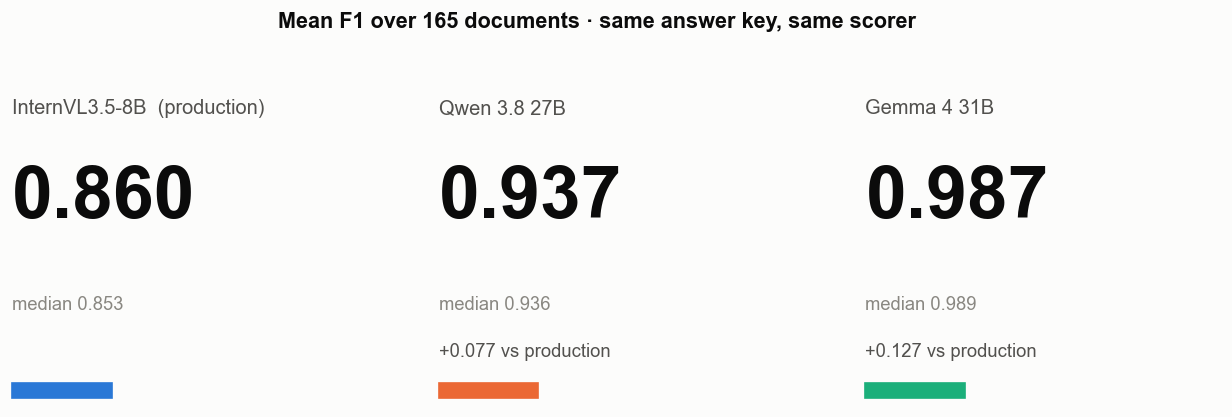

In [5]:
fig_headline, axes = plt.subplots(1, 3, figsize=(13, 3.6))
fig_headline.suptitle(
    "Mean F1 over 165 documents · same answer key, same scorer", fontsize=13, fontweight="bold", y=1.02
)
prod_mean = summary.loc[PRODUCTION, "mean F1"]
for ax, model in zip(axes, MODELS):
    mean, median = summary.loc[model, "mean F1"], summary.loc[model, "median F1"]
    ax.set_axis_off()
    ax.text(
        0.0,
        0.92,
        model + ("  (production)" if model == PRODUCTION else ""),
        fontsize=12,
        color=INK_2,
        va="top",
    )
    ax.text(0.0, 0.62, f"{mean:.3f}", fontsize=44, fontweight="semibold", color=INK, va="center")
    ax.text(0.0, 0.30, f"median {median:.3f}", fontsize=11, color=MUTED, va="center")
    if model != PRODUCTION:
        ax.text(0.0, 0.16, f"{mean - prod_mean:+.3f} vs production", fontsize=11, color=INK_2, va="center")
    # identity swatch: the mark carries the colour, the text never does
    ax.add_patch(
        plt.Rectangle(
            (0.0, 0.02), 0.28, 0.045, color=MODEL_COLOUR[model], transform=ax.transAxes, clip_on=False
        )
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.show()

## 2. Per-field F1

Rows are the seventeen production fields, sorted by the production model ascending so the
top of the chart is where switching buys the most. Three dots per row; only the widest
gaps are labelled.

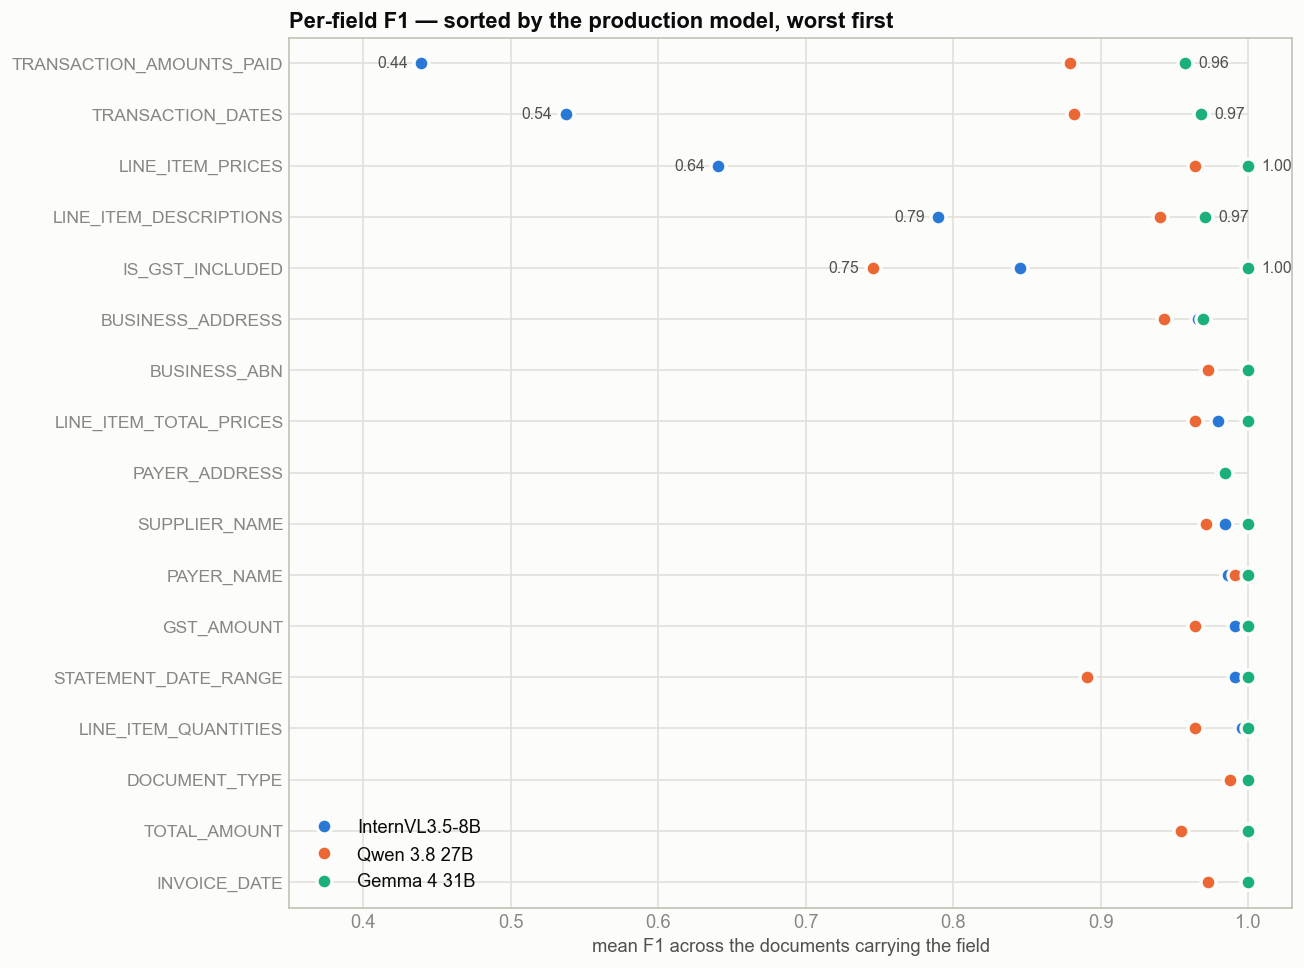

In [6]:
per_field = fields.groupby(["field", "model"]).f1.mean().unstack("model").reindex(columns=MODELS)
per_field = per_field.sort_values(PRODUCTION)
gap = per_field.max(axis=1) - per_field.min(axis=1)
label_rows = set(gap.sort_values(ascending=False).index[:5])

fig_fields, ax = plt.subplots(figsize=(11, 8.2))
y = np.arange(len(per_field))
ax.set_yticks(y)
ax.set_yticklabels(per_field.index, fontsize=10.5)
ax.grid(axis="x", color=GRID, linewidth=1)
ax.grid(axis="y", visible=False)
for i in y:
    ax.plot([0, 1], [i, i], color=GRID, linewidth=1, zorder=1)
for model in MODELS:
    ax.plot(
        per_field[model].values,
        y,
        linestyle="none",
        marker="o",
        markersize=9,
        markerfacecolor=MODEL_COLOUR[model],
        markeredgecolor=SURFACE,
        markeredgewidth=2,
        label=model,
        zorder=3,
    )
for i, field in enumerate(per_field.index):
    if field in label_rows:
        lo, hi = per_field.loc[field].min(), per_field.loc[field].max()
        ax.annotate(
            f"{lo:.2f}",
            (lo, i),
            xytext=(-8, 0),
            textcoords="offset points",
            ha="right",
            va="center",
            fontsize=9.5,
            color=INK_2,
        )
        ax.annotate(
            f"{hi:.2f}",
            (hi, i),
            xytext=(8, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9.5,
            color=INK_2,
        )
ax.set_xlim(0.35, 1.03)
ax.set_xlabel("mean F1 across the documents carrying the field")
ax.set_title("Per-field F1 — sorted by the production model, worst first", loc="left")
ax.legend(loc="lower left", ncol=1)  # bottom-left is the one empty corner: every dot there sits near 1.0
ax.set_ylim(len(per_field) - 0.5, -0.5)  # worst-for-production at the TOP
plt.tight_layout()
plt.show()

## 3. By document type

The bank-statement column is the story: the dense-table problem that has been the
project's bottleneck since May.

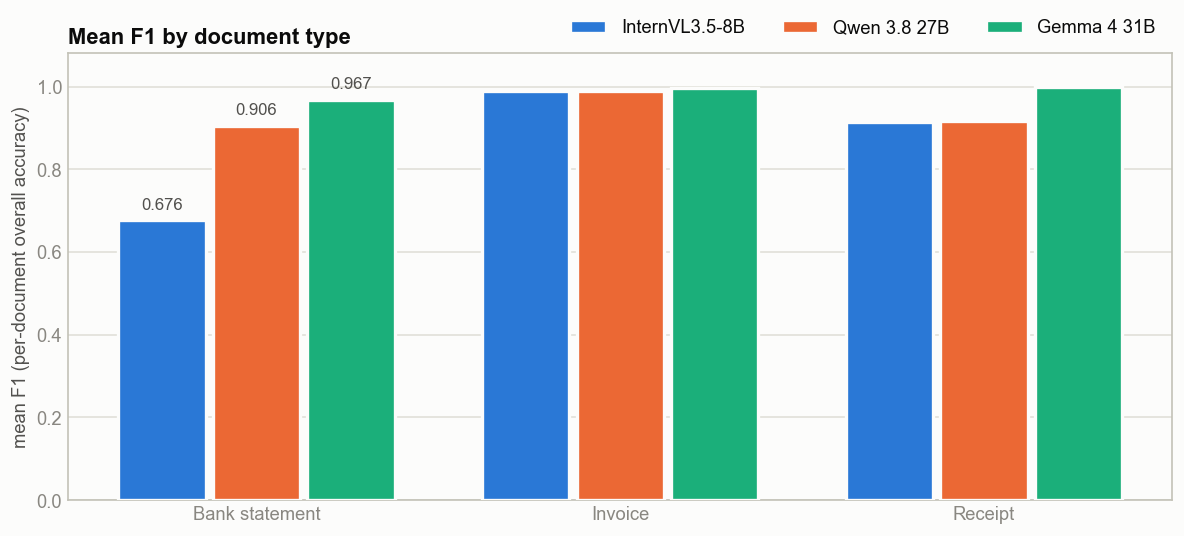

In [7]:
by_type = (
    docs.groupby(["document_type", "model"])
    .overall_accuracy.mean()
    .unstack("model")
    .reindex(index=DOC_ORDER, columns=MODELS)
)

fig_doctype, ax = plt.subplots(figsize=(10, 4.6))
x = np.arange(len(DOC_ORDER))
width = 0.24
for k, model in enumerate(MODELS):
    vals = by_type[model].values
    bars = ax.bar(
        x + (k - 1) * (width + 0.02),
        vals,
        width,
        color=MODEL_COLOUR[model],
        edgecolor=SURFACE,
        linewidth=2,
        label=model,
        zorder=3,
    )
    if True:  # label the bank-statement group only (the story), at the bar cap
        ax.annotate(
            f"{vals[0]:.3f}",
            (x[0] + (k - 1) * (width + 0.02), vals[0]),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            color=INK_2,
        )
ax.set_xticks(x)
ax.set_xticklabels([DOC_LABEL[d] for d in DOC_ORDER])
ax.set_ylim(0, 1.08)
ax.set_ylabel("mean F1 (per-document overall accuracy)")
ax.grid(axis="x", visible=False)
ax.set_title("Mean F1 by document type", loc="left")
ax.legend(
    loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=3
)  # above the plot, right of the left-anchored title
plt.tight_layout()
plt.show()

## 4. Every document

One dot per document. Qwen's six bank statements at the floor and InternVL's spread across
the table fields are what the averages hide; Gemma's cluster at the top is the point.

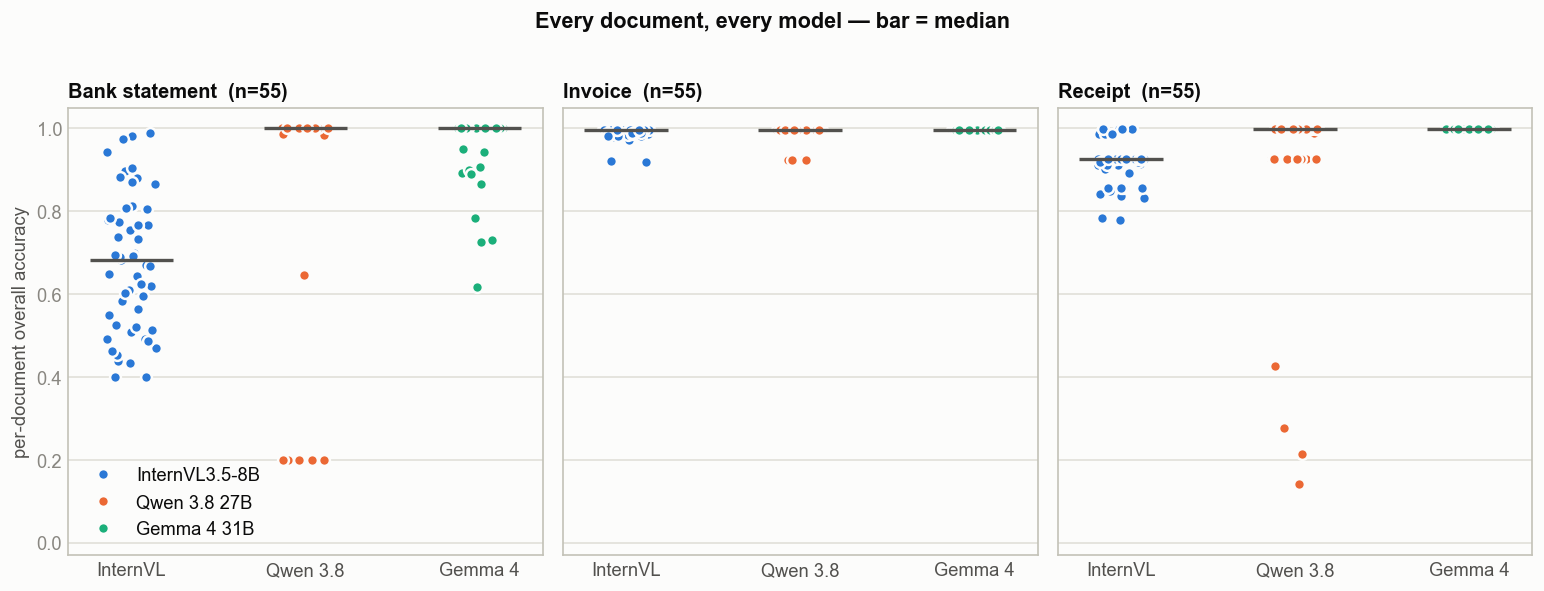

In [8]:
rng = np.random.default_rng(7)
fig_dist, axes = plt.subplots(1, 3, figsize=(13, 4.8), sharey=True)
for ax, doc_type in zip(axes, DOC_ORDER):
    sub = docs[docs.document_type == doc_type]
    for k, model in enumerate(MODELS):
        vals = sub[sub.model == model].overall_accuracy.values
        xs = k + rng.uniform(-0.14, 0.14, size=len(vals))
        ax.plot(
            xs,
            vals,
            linestyle="none",
            marker="o",
            markersize=6.5,
            markerfacecolor=MODEL_COLOUR[model],
            markeredgecolor=SURFACE,
            markeredgewidth=1.5,
            zorder=3,
            label=model if doc_type == DOC_ORDER[0] else None,
        )
        ax.hlines(np.median(vals), k - 0.24, k + 0.24, color=INK_2, linewidth=2, zorder=4)
    ax.set_xticks(range(len(MODELS)))
    ax.set_xticklabels(["InternVL", "Qwen 3.8", "Gemma 4"], color=INK_2)
    ax.set_title(f"{DOC_LABEL[doc_type]}  (n={len(sub) // len(MODELS)})", loc="left", fontsize=12)
    ax.grid(axis="x", visible=False)
    ax.set_ylim(-0.03, 1.05)
axes[0].set_ylabel("per-document overall accuracy")
fig_dist.suptitle("Every document, every model — bar = median", fontsize=13, fontweight="bold", y=1.02)
axes[0].legend(loc="lower left")
plt.tight_layout()
plt.show()

## 5. Time to extract 165 documents

Engine load and inference, from the extract stage's own timing. Topology is forced by
memory, not chosen: an 8B holds one engine per 24 GiB card and runs two, while both larger
models are sharded across the pair and run one — so InternVL's lead here is topology. On
the 4× A10G production hardware with DP=2 × tp=2, most of it closes.

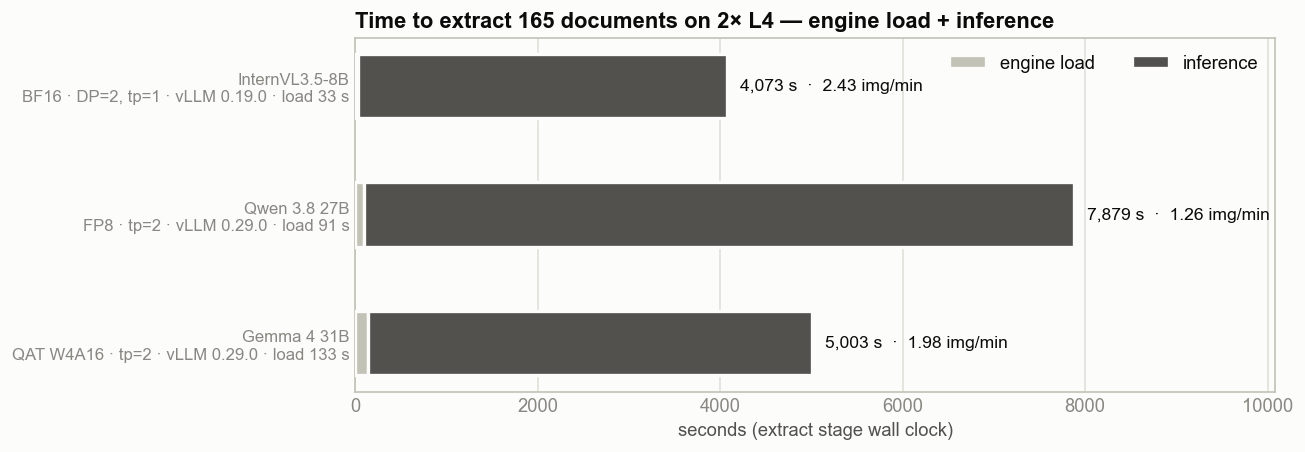

In [9]:
# Part-to-whole within one bar: two ink steps, not a series colour -- the model is named on
# the axis, and painting the stack blue would read as "InternVL" on every row.
LOAD_STEP, INFER_STEP = BASELINE, INK_2

fig_time, ax = plt.subplots(figsize=(11, 3.9))
y = np.arange(len(MODELS))
loads = np.array([timing[m]["engine_load_s"] for m in MODELS])
infers = np.array([timing[m]["inference_s"] for m in MODELS])
ax.barh(
    y, loads, height=0.5, color=LOAD_STEP, edgecolor=SURFACE, linewidth=2, label="engine load", zorder=3
)
ax.barh(
    y,
    infers,
    height=0.5,
    left=loads,
    color=INFER_STEP,
    edgecolor=SURFACE,
    linewidth=2,
    label="inference",
    zorder=3,
)
for i, model in enumerate(MODELS):
    total = loads[i] + infers[i]
    ax.annotate(
        f"{total:,.0f} s  ·  {N_DOCS / (total / 60):.2f} img/min",
        (total, i),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=10.5,
        color=INK,
    )
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{m}\n{MODEL_SERVED[m]} · load {timing[m]['engine_load_s']:.0f} s" for m in MODELS], fontsize=10
)
ax.invert_yaxis()
ax.set_xlim(0, max(loads + infers) * 1.28)
ax.set_xlabel("seconds (extract stage wall clock)")
ax.grid(axis="y", visible=False)
ax.set_title("Time to extract 165 documents on 2× L4 — engine load + inference", loc="left")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

## 5b. What tp=2 on 2× L4 costs, and what 4× A10G gives back

**Why the big models were slower here.** Neither 27B nor 31B fits one 24 GiB card, so each
was sharded across both L4s (tp=2) and the cluster ran **one** engine. The 8B fits on a
card, so it ran **two** independent engines (DP=2), each taking half the documents. The
pipeline is embarrassingly parallel across documents — no document depends on another — so
engine count converts almost directly into throughput. Tensor parallelism does not: every
decode step pays an all-reduce over PCIe, and the two cards' compute is spent on *one*
sequence at a time. The measured gap is therefore mostly **one engine versus two**, not
model size.

**Production is 4× A10G.** Each A10G is also 24 GiB, so the per-engine fit is identical to
what was measured (Gemma 10.9 GiB weights + 8.0 GiB KV per card at tp=2). Four cards give:

| model | 2× L4 (measured) | 4× A10G (production) | engines |
|---|---|---|---|
| InternVL3.5-8B | DP=2, tp=1 | DP=4, tp=1 | 2 → 4 |
| Qwen 3.8 27B | tp=2 | DP=2 × tp=2 | 1 → 2 |
| Gemma 4 31B | tp=2 | DP=2 × tp=2 | 1 → 2 |

Every model doubles its engine count, so the **floor** projection halves inference time
for all three and keeps engine load unchanged (engines load in parallel). Two things to
hold this against: DP=2 × tp=2 **is not implemented yet** — the current code would pick
tp=4 on a four-card box, the topology that deadlocked the link stage — and the floor
carries the per-card speed over from L4 unadjusted. The next section puts a number on
what the A10G card itself adds.

## 5c. Bank statements are the workload — and they are decode-bound

A10G's vendor spec-sheet memory bandwidth is twice L4's (600 vs 300 GB/s); its tensor
throughput is not higher. That matters because generating each output token streams the
model's weight shard from memory once (**decode**, bandwidth-bound), while reading the
image and prompt is one large matrix pass (**prefill**, compute-bound). The card helps
exactly in proportion to how much of a document's time is decode.

The extract stage records a wall clock per image. Fitting it against response length,
per model and document type, splits each document into a fixed part and a per-character
part; the per-character slope is decode. Bank statements — 80–93% of each model's
inference seconds — show it clearly for all three models. For the two large models,
invoices and receipts finish in ~3–15 s over a ~200-character spread and no slope is
identifiable (R² ≈ 0); InternVL's short documents, by contrast, fit almost perfectly
(R² 0.98) with a zero fixed part — that model is decode-bound on everything.

Qwen's fit is the weakest (R² 0.50) for a visible reason: its six blank bank statements
sit at the far left of the scatter — ~190 characters, yet 104–144 s each. That is the
full prefill of an ~11×-larger image with nothing decoded, which is also why its fixed
part (74 s) is three times Gemma's.

One corroboration that the slope really is weight streaming: InternVL (16 GiB of BF16
weights on one card) and Gemma (10.9 GiB of W4A16 per card, two cards in parallel) land
within 20% of each other per character, as a bandwidth-bound decode would.

In [10]:
BANDWIDTH_GBPS = {"L4": 300, "A10G": 600}  # vendor spec-sheet GDDR6 memory bandwidth
DECODE_SPEEDUP = BANDWIDTH_GBPS["A10G"] / BANDWIDTH_GBPS["L4"]
FIT_R2_FLOOR = 0.5  # below this the fit explains nothing and no decode term is claimed

fit_rows, fit_params = [], {}
for model in MODELS:
    model_images = images[images.model == model]
    for doc_type in DOC_ORDER:
        sub = model_images[model_images.document_type == doc_type]
        slope, intercept = np.polyfit(sub.chars, sub.processing_time, 1)
        predicted = intercept + slope * sub.chars
        r2 = (
            1
            - ((sub.processing_time - predicted) ** 2).sum()
            / ((sub.processing_time - sub.processing_time.mean()) ** 2).sum()
        )
        fit_params[(model, doc_type)] = (intercept, slope, r2)
        fit_rows.append(
            {
                "model": model,
                "document type": DOC_LABEL[doc_type],
                "n": len(sub),
                "s per document": sub.processing_time.mean(),
                "share of inference": sub.processing_time.sum() / model_images.processing_time.sum(),
                "fixed s": intercept,
                "ms per char": slope * 1000,
                "R²": r2,
            }
        )
fit = pd.DataFrame(fit_rows).set_index(["model", "document type"])
display(
    fit.style.format(
        {
            "s per document": "{:.1f}",
            "share of inference": "{:.0%}",
            "fixed s": "{:.1f}",
            "ms per char": "{:.1f}",
            "R²": "{:.2f}",
        }
    )
)

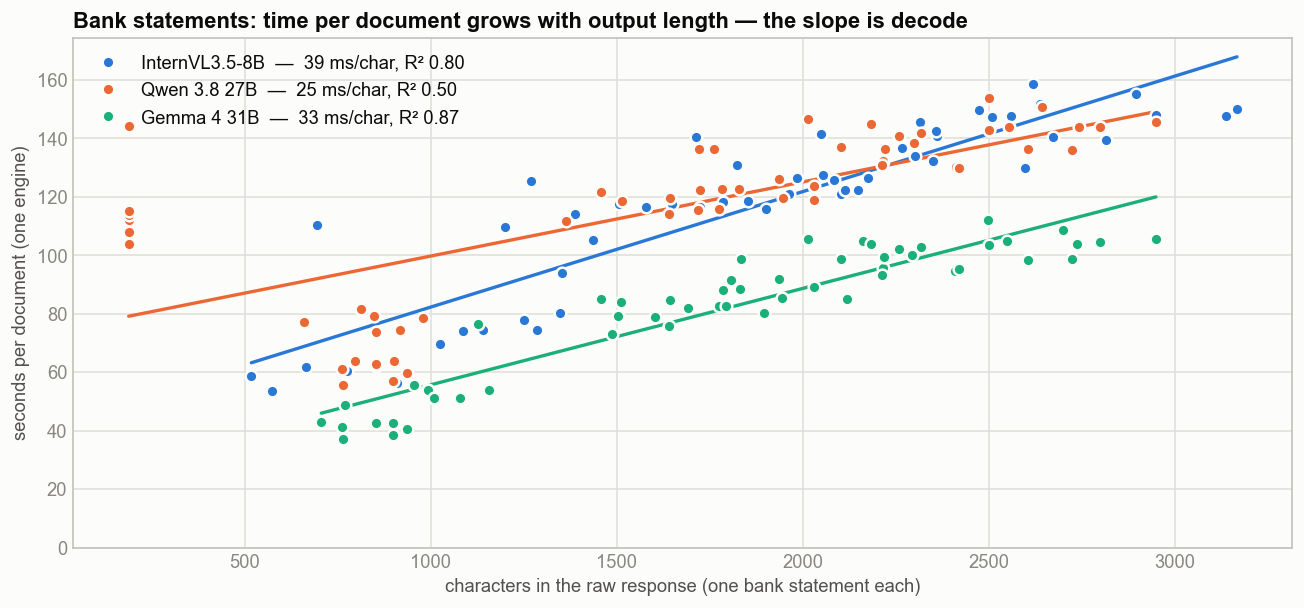

In [11]:
fig_fit, ax = plt.subplots(figsize=(11, 5.2))
bank = images[images.document_type == "BANK_STATEMENT"]
for model in MODELS:
    sub = bank[bank.model == model]
    intercept, slope, r2 = fit_params[(model, "BANK_STATEMENT")]
    ax.plot(
        sub.chars,
        sub.processing_time,
        linestyle="none",
        marker="o",
        markersize=7,
        markerfacecolor=MODEL_COLOUR[model],
        markeredgecolor=SURFACE,
        markeredgewidth=1.5,
        zorder=3,
        label=f"{model}  —  {slope * 1000:.0f} ms/char, R² {r2:.2f}",
    )
    xs = np.array([sub.chars.min(), sub.chars.max()])
    ax.plot(xs, intercept + slope * xs, color=MODEL_COLOUR[model], linewidth=2, zorder=2)
ax.set_xlabel("characters in the raw response (one bank statement each)")
ax.set_ylabel("seconds per document (one engine)")
ax.set_ylim(0, None)
ax.set_title(
    "Bank statements: time per document grows with output length — the slope is decode", loc="left"
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Applying A10G's bandwidth to the decode term wherever the fit identifies one (R² ≥ 0.5:
every document type for InternVL, bank statements for Qwen and Gemma; the term is halved,
the fixed part is unchanged) gives an upper projection alongside the floor. The truth
sits between them and nearer the upper: the fixed part of a bank statement is tens of
seconds, far more than a prefill of a few hundred tokens costs, so it holds decode too.
If A10G's tensor throughput turns out lower than L4's — spec sheets differ — the prefill
term grows, and Qwen, whose bank statements are prefill-heavy (large fixed part, ~11×
the visual tokens), is the most exposed.

In [12]:
ENGINES_PROD = {"InternVL3.5-8B": 4, "Qwen 3.8 27B": 2, "Gemma 4 31B": 2}
PROD_TOPOLOGY = {
    "InternVL3.5-8B": "DP=4, tp=1",
    "Qwen 3.8 27B": "DP=2 × tp=2",
    "Gemma 4 31B": "DP=2 × tp=2",
}

projection = []
for model in MODELS:
    t = timing[model]
    model_images = images[images.model == model]
    engine_share = ENGINES_MEASURED[model] / ENGINES_PROD[model]
    floor = t["engine_load_s"] + t["inference_s"] * engine_share

    # Bandwidth-adjusted: per-image engine-seconds with the decode term halved wherever the
    # fit identifies one; a document type whose fit explains nothing keeps its measured time.
    adjusted = model_images.processing_time.copy()
    for doc_type in DOC_ORDER:
        intercept, slope, r2 = fit_params[(model, doc_type)]
        if r2 >= FIT_R2_FLOOR:
            rows_of_type = model_images.document_type == doc_type
            adjusted[rows_of_type] = (
                intercept + slope * model_images.loc[rows_of_type, "chars"] / DECODE_SPEEDUP
            )
    bandwidth_factor = adjusted.sum() / model_images.processing_time.sum()
    upper = t["engine_load_s"] + t["inference_s"] * bandwidth_factor * engine_share
    is_bank = model_images.document_type == "BANK_STATEMENT"
    adjusted_bank = adjusted[is_bank]

    projection.append(
        {
            "model": model,
            "measured s (2× L4)": t["extract_wall_s"],
            "measured img/min": N_DOCS / (t["extract_wall_s"] / 60),
            "floor s (4× A10G, engines ×2)": floor,
            "floor img/min": N_DOCS / (floor / 60),
            "with bandwidth s (4× A10G)": upper,
            "with bandwidth img/min": N_DOCS / (upper / 60),
            "bank statement s/doc: L4 → A10G": f"{model_images.loc[is_bank, 'processing_time'].mean():.0f} → {adjusted_bank.mean():.0f}",
            "production topology": PROD_TOPOLOGY[model],
        }
    )
projection = pd.DataFrame(projection).set_index("model")
display(
    projection.style.format(
        {c: "{:,.0f}" for c in projection.columns if c.endswith(" s (2× L4)") or " s (4× A10G" in c}
        | {c: "{:.2f}" for c in projection.columns if c.endswith("img/min")}
    )
)

for column in ("measured img/min", "floor img/min", "with bandwidth img/min"):
    print(
        f"{column:24s} Gemma / InternVL = {projection.loc['Gemma 4 31B', column] / projection.loc[PRODUCTION, column]:.0%}"
    )
print(
    f"Gemma on 4xA10G vs InternVL as it runs today on 2xL4: {projection.loc['Gemma 4 31B', 'floor img/min'] / projection.loc[PRODUCTION, 'measured img/min']:.2f}x (floor) to {projection.loc['Gemma 4 31B', 'with bandwidth img/min'] / projection.loc[PRODUCTION, 'measured img/min']:.2f}x (with bandwidth)"
)

,measured s (2× L4),measured img/min,"floor s (4× A10G, engines ×2)",floor img/min,with bandwidth s (4× A10G),with bandwidth img/min,bank statement s/doc: L4 → A10G,production topology
model,,,,,,,,
InternVL3.5-8B,"4,073",2.43,"2,053",4.82,"1,332",7.43,115 → 79,"DP=4, tp=1"
Qwen 3.8 27B,"7,879",1.26,"3,985",2.48,"3,423",2.89,115 → 95,DP=2 × tp=2
Gemma 4 31B,"5,003",1.98,"2,568",3.85,"1,754",5.64,82 → 52,DP=2 × tp=2


measured img/min         Gemma / InternVL = 81%
floor img/min            Gemma / InternVL = 80%
with bandwidth img/min   Gemma / InternVL = 76%
Gemma on 4xA10G vs InternVL as it runs today on 2xL4: 1.59x (floor) to 2.32x (with bandwidth)


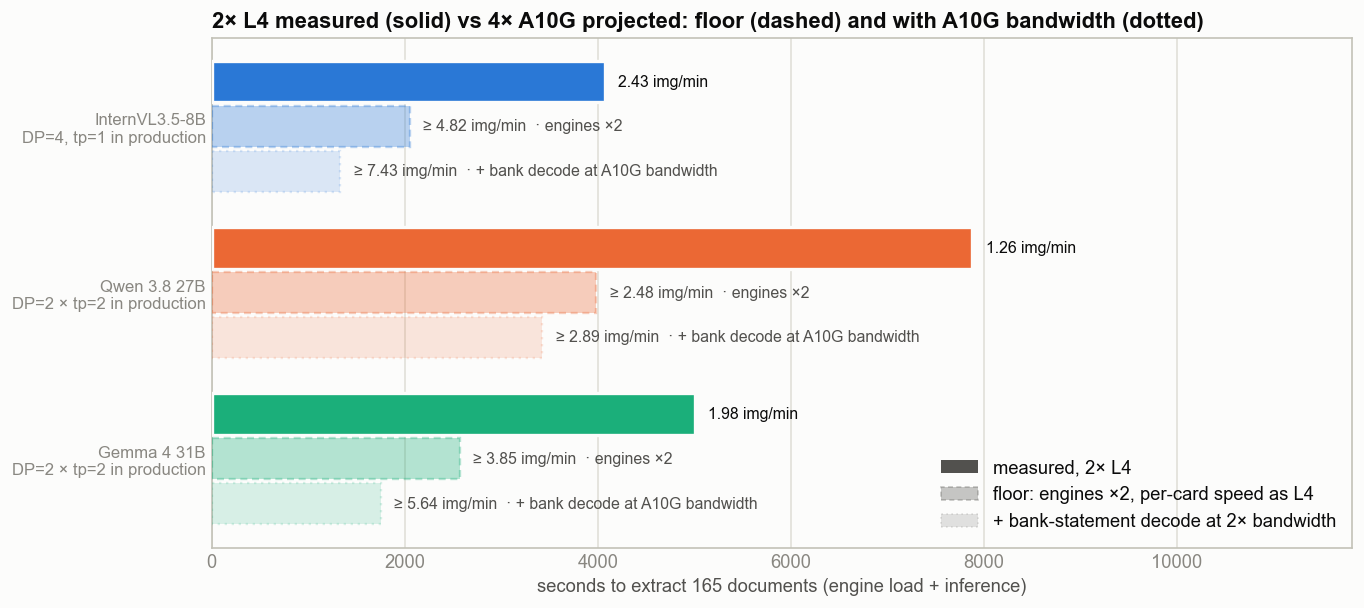

In [13]:
fig_prod, ax = plt.subplots(figsize=(11.5, 5.2))
y = np.arange(len(MODELS))
h = 0.25
gap = 0.02
series = (
    ("measured s (2× L4)", "measured img/min", 1.0, "solid", "{v:.2f} img/min"),
    (
        "floor s (4× A10G, engines ×2)",
        "floor img/min",
        0.32,
        (0, (3, 2)),
        "≥ {v:.2f} img/min  · engines ×2",
    ),
    (
        "with bandwidth s (4× A10G)",
        "with bandwidth img/min",
        0.16,
        (0, (1, 2)),
        "≥ {v:.2f} img/min  · + bank decode at A10G bandwidth",
    ),
)
for i, model in enumerate(MODELS):
    c = MODEL_COLOUR[model]
    for k, (col_s, col_rate, alpha, style, label) in enumerate(series):
        yy = y[i] + (k - 1) * (h + gap)
        value = projection.loc[model, col_s]
        if k == 0:
            ax.barh(yy, value, height=h, color=c, edgecolor=SURFACE, linewidth=2, zorder=3)
        else:  # projections: same hue, lighter fill, dashed edge -- estimates, not measurements
            ax.barh(
                yy,
                value,
                height=h,
                facecolor=c,
                alpha=alpha,
                edgecolor=c,
                linestyle=style,
                linewidth=1.4,
                zorder=3,
            )
        ax.annotate(
            label.format(v=projection.loc[model, col_rate]),
            (value, yy),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=9.5,
            color=INK if k == 0 else INK_2,
        )
ax.set_yticks(y)
ax.set_yticklabels([f"{m}\n{PROD_TOPOLOGY[m]} in production" for m in MODELS], fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, projection["measured s (2× L4)"].max() * 1.5)
ax.set_xlabel("seconds to extract 165 documents (engine load + inference)")
ax.grid(axis="y", visible=False)
ax.set_title(
    "2× L4 measured (solid) vs 4× A10G projected: floor (dashed) and with A10G bandwidth (dotted)",
    loc="left",
)
ax.legend(
    handles=[
        Patch(facecolor=INK_2, label="measured, 2× L4"),
        Patch(
            facecolor=INK_2,
            alpha=0.32,
            edgecolor=INK_2,
            linestyle=(0, (3, 2)),
            label="floor: engines ×2, per-card speed as L4",
        ),
        Patch(
            facecolor=INK_2,
            alpha=0.16,
            edgecolor=INK_2,
            linestyle=(0, (1, 2)),
            label="+ bank-statement decode at 2× bandwidth",
        ),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.show()

## 6. How much each model writes per document

Median raw-response length. Qwen reasons in plain text on 107 of its 165 documents despite
thinking being disabled — it closes a think block it never opened — and produces about
three times the output of the other two. That is a large share of its slower inference,
and the cause of the four receipts it never finished.

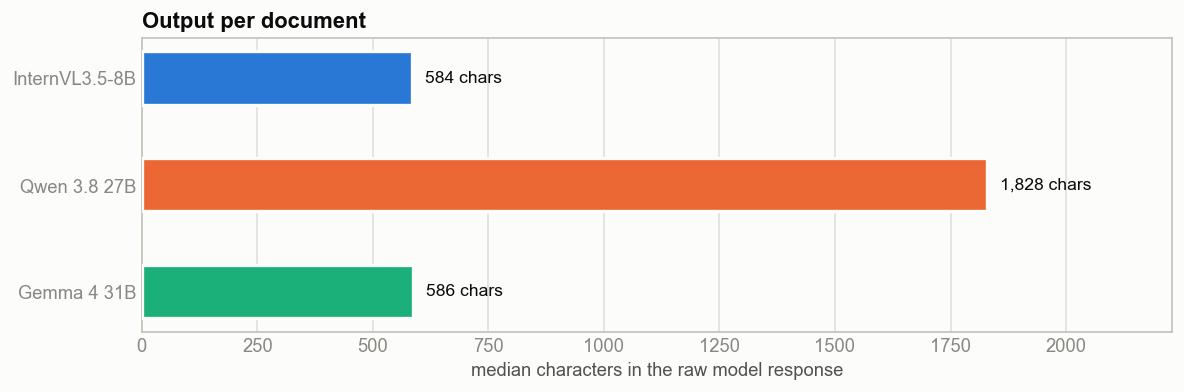

In [14]:
fig_length, ax = plt.subplots(figsize=(10, 3.4))
medians = [np.median(lengths[m]) for m in MODELS]
ax.barh(
    range(len(MODELS)),
    medians,
    height=0.5,
    color=[MODEL_COLOUR[m] for m in MODELS],
    edgecolor=SURFACE,
    linewidth=2,
    zorder=3,
)
for i, v in enumerate(medians):
    ax.annotate(
        f"{v:,.0f} chars",
        (v, i),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=10.5,
        color=INK,
    )
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels(MODELS)
ax.invert_yaxis()
ax.set_xlim(0, max(medians) * 1.22)
ax.set_xlabel("median characters in the raw model response")
ax.grid(axis="y", visible=False)
ax.set_title("Output per document", loc="left")
plt.tight_layout()
plt.show()

## Export for slides

In [15]:
FIG_DIR = Path(os.environ.get("LMM_FIG_DIR", REPO_ROOT / "notebooks" / "figures" / "three_way_20260922"))
FIG_DIR.mkdir(parents=True, exist_ok=True)
for name, figure in (
    ("01_headline_mean_f1", fig_headline),
    ("02_per_field_f1", fig_fields),
    ("03_by_document_type", fig_doctype),
    ("04_every_document", fig_dist),
    ("05_time_to_extract", fig_time),
    ("05b_projected_4xa10g", fig_prod),
    ("05c_bank_statement_decode_fit", fig_fit),
    ("06_output_per_document", fig_length),
):
    for extension in ("svg", "png"):
        path = FIG_DIR / f"{name}.{extension}"
        figure.savefig(path, format=extension, bbox_inches="tight", dpi=200)
        print(f"wrote {path.relative_to(REPO_ROOT)}")

wrote notebooks/figures/three_way_20260922/01_headline_mean_f1.svg
wrote notebooks/figures/three_way_20260922/01_headline_mean_f1.png


wrote notebooks/figures/three_way_20260922/02_per_field_f1.svg
wrote notebooks/figures/three_way_20260922/02_per_field_f1.png


wrote notebooks/figures/three_way_20260922/03_by_document_type.svg


wrote notebooks/figures/three_way_20260922/03_by_document_type.png
wrote notebooks/figures/three_way_20260922/04_every_document.svg


wrote notebooks/figures/three_way_20260922/04_every_document.png


wrote notebooks/figures/three_way_20260922/05_time_to_extract.svg
wrote notebooks/figures/three_way_20260922/05_time_to_extract.png
wrote notebooks/figures/three_way_20260922/05b_projected_4xa10g.svg


wrote notebooks/figures/three_way_20260922/05b_projected_4xa10g.png


wrote notebooks/figures/three_way_20260922/05c_bank_statement_decode_fit.svg
wrote notebooks/figures/three_way_20260922/05c_bank_statement_decode_fit.png
wrote notebooks/figures/three_way_20260922/06_output_per_document.svg


wrote notebooks/figures/three_way_20260922/06_output_per_document.png


## Key takeaways

- **Gemma 4 31B leads on every field** — mean F1 0.987 against 0.860 for the production
  model and 0.937 for Qwen 3.8 — and the gain is concentrated where it matters: bank
  transaction amounts 0.957 vs 0.439 and dates 0.968 vs 0.537.
- **Qwen's deficit is mostly not reading.** 22 of its failures are one under-defined field
  (`IS_GST_INCLUDED`), 6 are bank statements it returned nothing for, and 4 are receipts
  cut off by the token budget after it reasoned in plain text — which it does on 107 of
  165 documents with thinking supposedly off.
- **InternVL's deficit is reading dense tables** — every field populated, about half the
  rows wrong — plus 39 receipts where it declined to infer a unit price the answer key
  expects.
- **Throughput ranks by topology, not model.** On 2× L4 the 8B runs two engines and the
  two larger models one each, sharded (tp=2) — that, not model size, is most of the gap.
- **Bank statements are the workload and they are decode-bound.** 80–93% of each
  model's inference seconds are the 55 bank statements, and within them time rises
  linearly with output length (Gemma 33 ms/char, R² 0.87). Gemma's short documents
  take ~3 s each.
- **On the 4× A10G production box every model doubles its engines** (InternVL DP=4; Gemma
  and Qwen DP=2 × tp=2), and A10G's doubled memory bandwidth halves the decode term.
  Gemma projects to 3.9 img/min (engines only) up to 5.6 img/min (with bandwidth) —
  1.6–2.3× faster than production runs today on 2× L4, and 76–80% of what InternVL
  would do on the same four cards (InternVL gains more from bandwidth because it is
  decode-bound on every document type, not only bank statements). DP=2 × tp=2 must be implemented first; the current
  code would choose tp=4.
- Three scoring artefacts were found and fixed during this measurement; every historical
  figure carries the largest of them. Numbers here are on the corrected scorer.